In [2]:
scenic = pd.read_csv('../../eRegulon_direct_guang.tsv', delimiter = '\t')

In [3]:
otohomo = pd.read_csv('../../OTO_star_nothreshold_missing_le2_expressionthresh_08022026.tsv',delimiter='\t', index_col = 'MM')

In [4]:
orthogroups = pd.read_csv('../../Vert_emapper_allorgs_08012026.tsv',delimiter='\t', index_col = 'Unnamed: 0')

In [5]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [6]:
mm_mapping_ortho = orthogroup_mapper(orthogroups,'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups,'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups,'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups,'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups,'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [7]:
!pip install anndata==0.8.0

In [8]:
!pip install openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.3/251.3 kB 1.8 MB/s eta 0:00:0000:0100:01


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.spatial import distance
import os
import scipy
from tqdm import tqdm
import matplotlib as mpl

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
sam_mg = SAM()
sam_mg.load_data('../../Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')
gene_dict_mg = {}
for i in range(len(sam_mg.adata.var_names)):
    gene_dict_mg[sam_mg.adata.var_names[i]] = i

In [8]:
sam_mo = SAM()
sam_mo.load_data('../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_NN_04142026.h5ad')
gene_dict_mo = {}
for i in range(len(sam_mo.adata.var_names)):
    gene_dict_mo[sam_mo.adata.var_names[i]] = i

In [9]:
sam_cj = SAM()
sam_cj.load_data('../../Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [10]:
sam_ac= SAM()
sam_ac.load_data('../../Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad')
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i

In [11]:
sam_xt = SAM()
sam_xt.load_data('../../Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad')
gene_dict_xt = {}
for i in range(len(sam_xt.adata.var_names)):
    gene_dict_xt[sam_xt.adata.var_names[i]] = i

In [12]:
sam_dr = SAM()
sam_dr.load_data('../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad')
gene_dict_dr = {}
for i in range(len(sam_dr.adata.var_names)):
    gene_dict_dr[sam_dr.adata.var_names[i]] = i

In [13]:
TF = pd.read_csv('../../Fin_TF_06012026.csv')
TF_set = set(TF['0']) 
neuropep = pd.read_csv('../../Neuropeptides_receptors_10202025.csv')
neuropep_list = list(neuropep['Neuropeptide names'].unique())

In [14]:
exp = sam_mg.adata.X.A
all_exp_ct = np.zeros((sam_mg.adata.obs['subclass_id_label'].nunique(),len(sam_mg.adata.var_names)))
ctl = sam_mg.adata.obs['subclass_id_label'].unique()
for i in range(len(ctl)):
    all_exp_ct[i,:] = np.average(exp[sam_mg.adata.obs['subclass_id_label'] == ctl[i],:], axis = 0)

In [15]:
with open('../../parent_dict_v2.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [38]:
sam_mo.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2',
       'neurotransmitter_v3'],
      dtype='object')

In [39]:
for item in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique():
    if item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
    if item[:2] == 'xt':
        parent_dict[item] = 'hypo'
    if item[:2] == 'cj':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mg':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ac':
        parent_dict[item] = 'hypo'
    if item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ri':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mo':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ct':
        parent_dict[item] = 'hypo'

In [21]:
parent_dict['hypo'] = 'hypo'
parent_dict['not hypo'] = 'not hypo'

In [22]:
df = pd.read_csv('../../Figures/Figures_07242026/Neuropep_TF_corr_hypo_07272026.csv',index_col = 'Unnamed: 0')

In [23]:
df

,"('Tac1', 'Ar')","('Tac2', 'Ar')","('Prok2', 'Dbp')","('Gal', 'Esr1')","('Pomc', 'Esr1')","('Agrp', 'Fli1')","('Vgf', 'Fos')","('Avp', 'Fosl2')","('Oxt', 'Fosl2')","('Vgf', 'Fosl2')",...,"('Apln', 'Nkx2-2')","('Npvf', 'Nkx2-2')","('Prok2', 'Nr1d1')","('Crh', 'Nr3c1')","('Tac2', 'Nr5a2')","('Gnrh1', 'Otx1')","('Crh', 'Pou3f2')","('Prok2', 'Pparg')","('Qrfp', 'Rfx2')","('Dbi', 'Tcf12')"
mm,0.405647,0.309298,0.597400,0.424799,0.332997,0.621393,0.397635,0.313507,0.446301,0.504516,...,0.361732,0.848023,0.732503,0.361370,0.314587,0.897795,0.411288,0.513059,0.466379,0.444830
mo,-0.029635,0.363362,0.584099,0.161575,0.378798,-0.023448,0.596499,0.502868,0.504534,0.160793,...,-0.106819,0.178497,0.586573,0.093301,-0.067749,0.051493,0.296989,0.237457,0.453217,0.186556
cj,-0.148931,NaN,NaN,0.199608,0.371958,0.171347,NaN,0.068376,-0.000046,NaN,...,0.146226,0.185558,0.122939,-0.053975,NaN,0.082971,0.047588,-0.059162,0.566230,0.070147
ac,-0.075712,-0.073211,-0.027884,-0.015180,-0.052711,-0.003418,0.066502,0.174518,0.139021,0.070305,...,NaN,0.453842,-0.107881,0.126454,-0.072212,NaN,0.175820,-0.047266,NaN,-0.167077
xt,-0.081831,-0.080881,0.045378,-0.017651,0.052398,0.068964,0.315526,0.239535,0.171970,0.497793,...,0.118044,0.226341,0.102527,0.038602,-0.013637,0.725307,0.222815,0.056130,0.236537,0.133188
dr,0.037018,NaN,NaN,0.429461,0.385159,-0.015304,0.239228,0.126126,0.199022,0.299245,...,NaN,NaN,-0.057565,NaN,NaN,NaN,0.068295,NaN,NaN,0.095794


In [24]:
import ast


mm_row = df.loc['mm',:]
tf_target_corrs = {}
for pair_label, r in mm_row.items():
    _, tf_gene = ast.literal_eval(pair_label)   # pair_label is "('NP', 'TF')"
    if pd.notna(r):
        tf_target_corrs.setdefault(tf_gene, []).append(float(r))

In [25]:
tf_target_corrs.keys()

dict_keys(['Ar', 'Dbp', 'Esr1', 'Fli1', 'Fos', 'Fosl2', 'Foxn4', 'Hlf', 'Hmx2', 'Hmx3', 'Isl1', 'Lhx9', 'Nkx2-1', 'Nkx2-2', 'Nr1d1', 'Nr3c1', 'Nr5a2', 'Otx1', 'Pou3f2', 'Pparg', 'Rfx2', 'Tcf12'])

In [26]:
import ast

# Number of unregulated control genes to pick per regulated NP-TF pair.
# n_controls = 1 reproduces the original "single best match" behavior.
n_controls = 5

TFl = tf_target_corrs.keys()
# For each TF, the mouse (mm) NP-TF correlations of its regulated pairs, read from
# df (the regulated NP-TF table). These per-pair values replace the single fixed
# 0.411287891721808: each control gene is matched to a specific regulated pair.
mm_row = df.loc['mm',:]
tf_target_corrs = {}
for pair_label, r in mm_row.items():
    _, tf_gene = ast.literal_eval(pair_label)   # pair_label is "('NP', 'TF')"
    if pd.notna(r):
        tf_target_corrs.setdefault(tf_gene, []).append(float(r))

neuropep_set = set(neuropep_list)

scenic_g_TF = []
mg_vals = []
for TF in TFl:
    tf_expr = all_exp_ct[:, gene_dict_mg[TF]]

    # genes this TF is annotated to regulate in SCENIC (excluded from the control)
    regulated_by_TF = set(scenic[scenic['TF'] == TF]['Gene'])

    # candidate control genes: present in the ortholog table and the mouse matrix,
    # not a neuropeptide, and NOT regulated by this TF; score each with pearsonr
    corrs = {}
    for g in dict.fromkeys(otohomo.index):
        if (g in gene_dict_mg and g != TF
                and g not in neuropep_set and g not in regulated_by_TF and g not in TF_set):
            r = stats.pearsonr(all_exp_ct[:, gene_dict_mg[g]], tf_expr)[0]
            if r > 0.3:
                corrs[g] = r
    corrs = pd.Series(corrs)

    # for each regulated pair's mouse correlation, take the n_controls closest
    # unused candidates (each candidate is used at most once)
    used = set()
    for target_r in tf_target_corrs[TF]:
        avail = corrs.drop(index=used, errors='ignore')
        if avail.empty:
            break
        closest = (avail - target_r).abs().nsmallest(n_controls).index
        for best in closest:
            used.add(best)
            scenic_g_TF.append((best, TF))
            mg_vals.append(corrs[best])

/scratch/miniconda/lib/python3.7/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())


In [27]:
len(scenic_g_TF)

155

In [28]:
len(df.columns)

31

In [29]:
stats.pearsonr(all_exp_ct[:,gene_dict_mg['Togaram1']],all_exp_ct[:,gene_dict_mg['Ar']])

(0.4056712838773413, 0.0003699610602926015)

In [30]:
scenic_np_tf_flat = [item for tup in scenic_g_TF for item in tup]

In [31]:
mg_exp ={i:i for i in scenic_np_tf_flat}
mo_exp = {i:otohomo.loc[i,'MO'] for i in scenic_np_tf_flat}
cj_exp = {i:otohomo.loc[i,'CJ'] for i in scenic_np_tf_flat}
ac_exp = {i:otohomo.loc[i,'AC'] for i in scenic_np_tf_flat}
xt_exp = {i:otohomo.loc[i,'XT'] for i in scenic_np_tf_flat}
dr_exp = {i:otohomo.loc[i,'DR'] for i in scenic_np_tf_flat}

In [32]:
df_corr = pd.DataFrame(columns = ['mm','mo','cj','ac','xt','dr'], index = scenic_g_TF)

In [33]:
df_corr['mm'] = mg_vals

In [34]:
def corr_org(org, adata, gene_name_conv, level, glist):
    fin_df = pd.DataFrame(index = glist, columns = [org])
    gene_dict = {gene: idx for idx, gene in enumerate(adata.var_names)}
    exp = adata.X.A
    all_exp_ct = np.zeros((adata.obs[level].nunique(),len(adata.var_names)))
    ctl = adata.obs[level].unique()
    for i in range(len(ctl)):
        all_exp_ct[i,:] = np.average(exp[adata.obs[level] == ctl[i],:], axis = 0)
    for item in glist:
        g1 = gene_name_conv[item[0]]
        g2 = gene_name_conv[item[1]]
        if type(g1) == str and type(g2) == str and g1 in gene_dict and g2 in gene_dict:
            fin_df.loc[[tuple(item)], org] = stats.pearsonr(all_exp_ct[:,gene_dict[g1]], all_exp_ct[:,gene_dict[g2]])[0]
    return(fin_df)

In [35]:
sam_cj.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [40]:
hl_mo = [i for i in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_cj = [i for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_ac = [i for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_xt = [i for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_dr = [i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [49]:
np.sort(hl_mo)

array(['066 NDB-SI-ant Prdm12 Gaba', '073 MEA-BST Sox6 Gaba',
       '074 MEA-BST Lhx6 Sp9 Gaba', '075 MEA-BST Lhx6 Nr2e1 Gaba',
       '076 MEA-BST Lhx6 Nfib Gaba', '077 CEA-BST Gal Avp Gaba',
       '078 SI-MA-ACB Ebf1 Bnc2 Gaba', '079 CEA-BST Six3 Cyp26b1 Gaba',
       '080 CEA-AAA-BST Six3 Sp9 Gaba', '081 ACB-BST-FS D1 Gaba',
       '082 CEA-BST Ebf1 Pdyn Gaba', '083 CEA-BST Rai14 Pdyn Crh Gaba',
       '084 BST-SI-AAA Six3 Slc22a3 Gaba', '085 SI-MPO-LPO Lhx8 Gaba',
       '086 MPO-ADP Lhx8 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '088 BST Tac2 Gaba', '089 PVR Six3 Sox3 Gaba',
       '090 BST-MPN Six3 Nrgn Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '093 RT-ZI Gnb3 Gaba',
       '094 SCH Six6 Cdc14a Gaba', '097 PVHd-SBPV Six3 Prox1 Gaba',
       '098 AHN-SBPV-PVHd Pdrm12 Gaba', '099 SBPV-PVa Six6 Satb2 Gaba',
       '100 AHN Onecut3 Gaba', '101 ZI Pax6 Gaba',
       '102 DMH-LHA Gsx1 Gaba', '103 PVHd-DMH Lhx6 Gaba',
       '104 TU-ARH Otp Six6 

In [42]:
hypo_adata_mo = sam_mo.adata[sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].isin(hl_mo)]
hypo_adata_cj = sam_cj.adata[sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].isin(hl_cj)]
hypo_adata_ac = sam_ac.adata[sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].isin(hl_ac)]
hypo_adata_xt = sam_xt.adata[sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].isin(hl_xt)]
hypo_adata_dr = sam_dr.adata[sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].isin(hl_dr)]

In [43]:
df_corr['mo'] = corr_org('mo',hypo_adata_mo,mo_exp,'ss_subclass_nounlabeled_03102026',df_corr.index)
df_corr['cj'] = corr_org('cj',hypo_adata_cj,cj_exp,'ss_subclass_nounlabeled_nmm_cl_v4_nn',df_corr.index)
df_corr['ac'] = corr_org('ac',hypo_adata_ac,ac_exp,'ss_subclass_nounlabeled_nmm_cl_v4_nn',df_corr.index)
df_corr['xt'] = corr_org('xt',hypo_adata_xt,xt_exp,'ss_subclass_nounlabeled_nmm_cl_v4_nn',df_corr.index)
df_corr['dr'] = corr_org('dr',hypo_adata_dr,dr_exp,'ss_subclass_nounlabeled_nmm_cl_v4_nn',df_corr.index)

In [44]:
df_corr = df_corr.T

In [45]:
swapped = [(b, a) for a, b in df_corr.columns]

# 2. Sort by the new first element (stable sort preserves relative order
#    within each group)
sorted_swapped = sorted(range(len(swapped)), key=lambda i: swapped[i][0])

# 3. Reindex columns
df_swapped = df_corr.iloc[:, sorted_swapped]

In [46]:
df_swapped = df_swapped.astype(float)

In [47]:
dfcorr_flat = list(set([item for tup in df_swapped.columns for item in tup]))

In [48]:
df_swapped

,"(Togaram1, Ar)","(Fam107a, Ar)","(Arfgap1, Ar)","(Ptbp2, Ar)","(Spopl, Ar)","(Trim3, Ar)","(Rnf157, Ar)","(Gng7, Ar)","(Jakmip2, Ar)","(Fam171b, Ar)",...,"(Creld2, Rfx2)","(Pias3, Rfx2)","(Ros1, Rfx2)","(Slc35d2, Rfx2)","(Il17rd, Rfx2)","(Nalcn, Tcf12)","(Dhx35, Tcf12)","(Usp44, Tcf12)","(Tmem88, Tcf12)","(Polr3d, Tcf12)"
mm,0.405671,0.405691,0.405857,0.406116,0.406163,0.309208,0.309062,0.309540,0.309553,0.308861,...,0.466251,0.466622,0.466083,0.466700,0.466732,0.444693,0.444548,0.445311,0.445334,0.445415
mo,0.101959,0.189971,-0.039482,0.267375,0.002679,0.141864,-0.111125,-0.019178,-0.153804,0.065463,...,0.171989,-0.038231,0.332086,0.366994,0.225862,0.234793,0.034713,0.157709,-0.104759,0.266363
cj,-0.001585,0.352071,-0.031157,0.161505,0.208897,0.183932,0.215818,0.068364,-0.078033,-0.067365,...,0.332599,NaN,0.010188,NaN,-0.134405,-0.245352,-0.250749,0.144981,NaN,-0.055645
ac,-0.007853,0.227002,0.122030,0.065577,0.062030,-0.166897,-0.150822,-0.092037,-0.014698,0.188794,...,NaN,NaN,NaN,NaN,NaN,0.105305,-0.072875,0.125478,-0.079080,0.133422
xt,0.216008,0.104730,0.137129,0.051350,0.200648,0.348628,0.029670,0.166419,0.445370,NaN,...,0.412834,0.194670,0.041011,0.420334,-0.024270,0.221350,0.202985,0.271425,-0.049683,0.120272
dr,NaN,-0.045083,0.055293,0.248242,0.278781,-0.057738,0.105961,0.205096,0.253164,0.250803,...,NaN,NaN,0.096503,0.183222,0.070179,0.608338,-0.024580,0.028708,-0.056873,-0.092096


In [50]:
df_swapped.to_csv('../../Figures/Figures_08022026/TF_unregulated_corr_hypo_ncontrols5_08032026.csv')

In [51]:
df_swapped = pd.read_csv('../../Figures/Figures_08022026/TF_unregulated_corr_hypo_ncontrols5_08032026.csv',index_col = 'Unnamed: 0')

In [52]:
df_swapped

,"('Togaram1', 'Ar')","('Fam107a', 'Ar')","('Arfgap1', 'Ar')","('Ptbp2', 'Ar')","('Spopl', 'Ar')","('Trim3', 'Ar')","('Rnf157', 'Ar')","('Gng7', 'Ar')","('Jakmip2', 'Ar')","('Fam171b', 'Ar')",...,"('Creld2', 'Rfx2')","('Pias3', 'Rfx2')","('Ros1', 'Rfx2')","('Slc35d2', 'Rfx2')","('Il17rd', 'Rfx2')","('Nalcn', 'Tcf12')","('Dhx35', 'Tcf12')","('Usp44', 'Tcf12')","('Tmem88', 'Tcf12')","('Polr3d', 'Tcf12')"
mm,0.405671,0.405691,0.405857,0.406116,0.406163,0.309208,0.309062,0.309540,0.309553,0.308861,...,0.466251,0.466622,0.466083,0.466700,0.466732,0.444693,0.444548,0.445311,0.445334,0.445415
mo,0.101959,0.189971,-0.039482,0.267375,0.002679,0.141864,-0.111125,-0.019178,-0.153804,0.065463,...,0.171989,-0.038231,0.332086,0.366994,0.225862,0.234793,0.034713,0.157709,-0.104759,0.266363
cj,-0.001585,0.352071,-0.031157,0.161505,0.208897,0.183932,0.215818,0.068364,-0.078033,-0.067365,...,0.332599,NaN,0.010188,NaN,-0.134405,-0.245352,-0.250749,0.144981,NaN,-0.055645
ac,-0.007853,0.227002,0.122030,0.065577,0.062030,-0.166897,-0.150822,-0.092037,-0.014698,0.188794,...,NaN,NaN,NaN,NaN,NaN,0.105305,-0.072875,0.125478,-0.079080,0.133422
xt,0.216008,0.104730,0.137129,0.051350,0.200648,0.348628,0.029670,0.166419,0.445370,NaN,...,0.412834,0.194670,0.041011,0.420334,-0.024270,0.221350,0.202985,0.271425,-0.049683,0.120272
dr,NaN,-0.045083,0.055293,0.248242,0.278781,-0.057738,0.105961,0.205096,0.253164,0.250803,...,NaN,NaN,0.096503,0.183222,0.070179,0.608338,-0.024580,0.028708,-0.056873,-0.092096


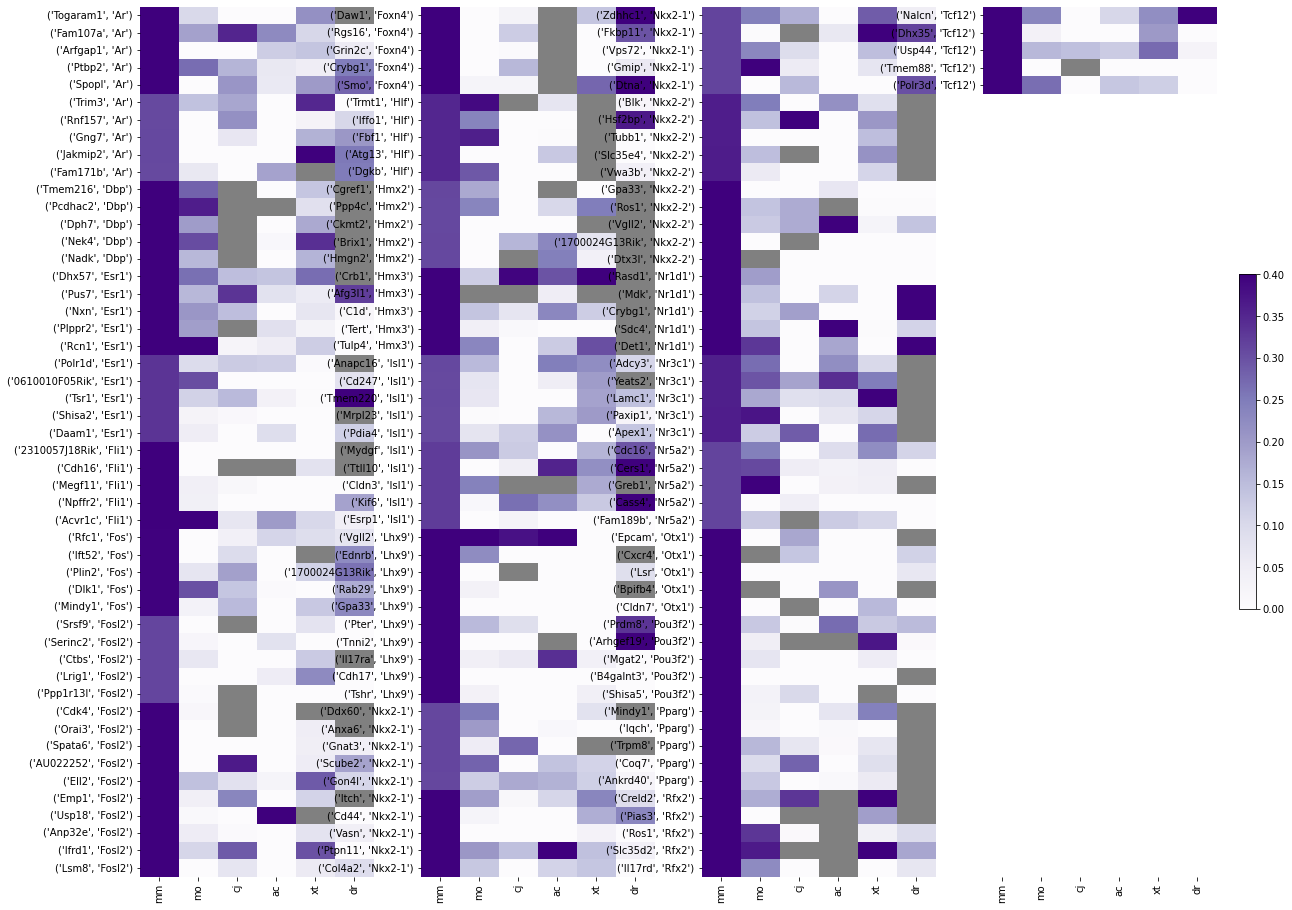

In [53]:
n_per_panel = 50
chunks = [df_swapped.iloc[:, i:i + n_per_panel].T
          for i in range(0, df_swapped.shape[1], n_per_panel)]

cmap = mpl.cm.get_cmap("Purples").copy()
cmap.set_bad('grey')  # sets NaN color

fig, axes = plt.subplots(1, len(chunks), figsize=(20, 16))

for ax, chunk in zip(axes, chunks):
    sns.heatmap(chunk, cmap=cmap, vmax=.4, vmin=0, ax=ax, cbar=False)
    # hold the cell height constant so the short final panel matches the full ones
    ax.set_ylim(n_per_panel, 0)
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=.4), cmap=cmap),
             ax=axes, fraction=.015, pad=.02)

plt.savefig('../../Figures/Figures_08022026/S35_RandomG_TF_relationship_ncontrols5_08032026.svg',bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_08022026/S35_RandomG_TF_relationship_ncontrols5_08032026.pdf',bbox_inches= 'tight')